/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



Explaining for class: setosa


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 602.94it/s]


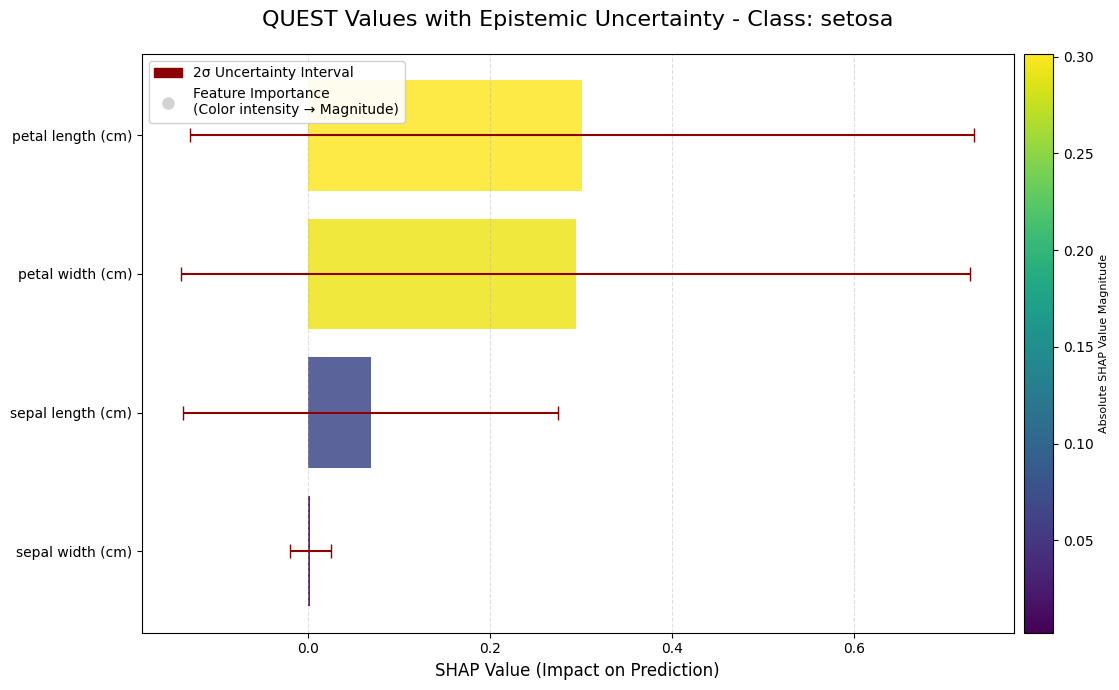

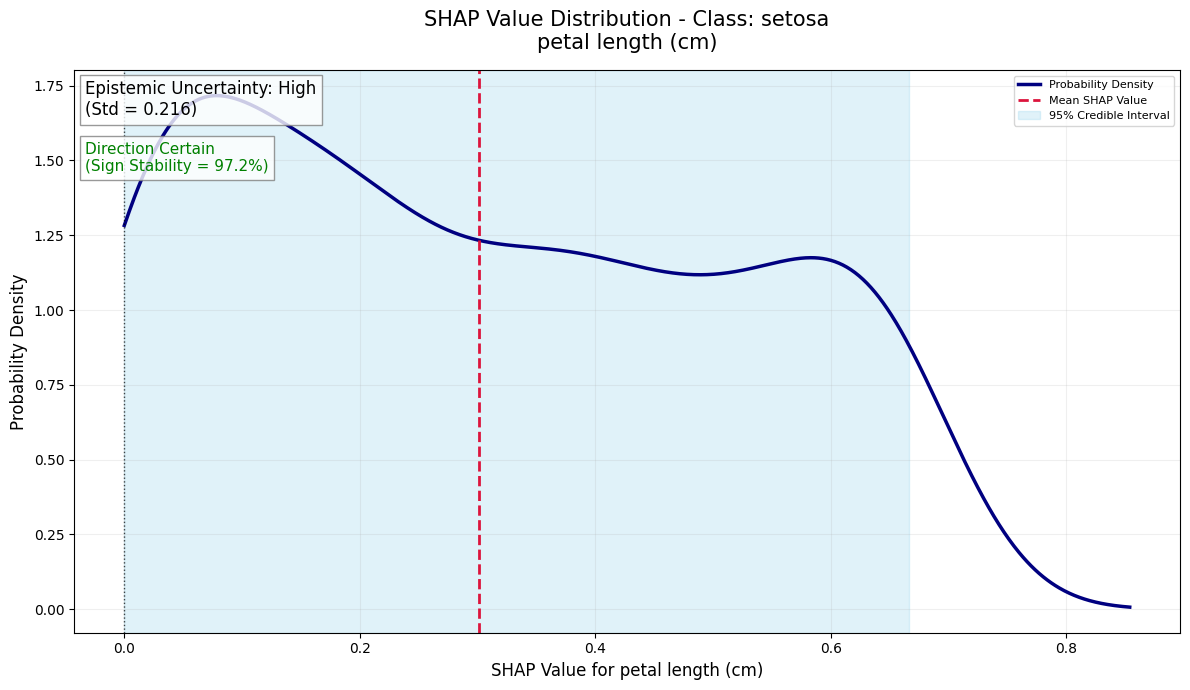

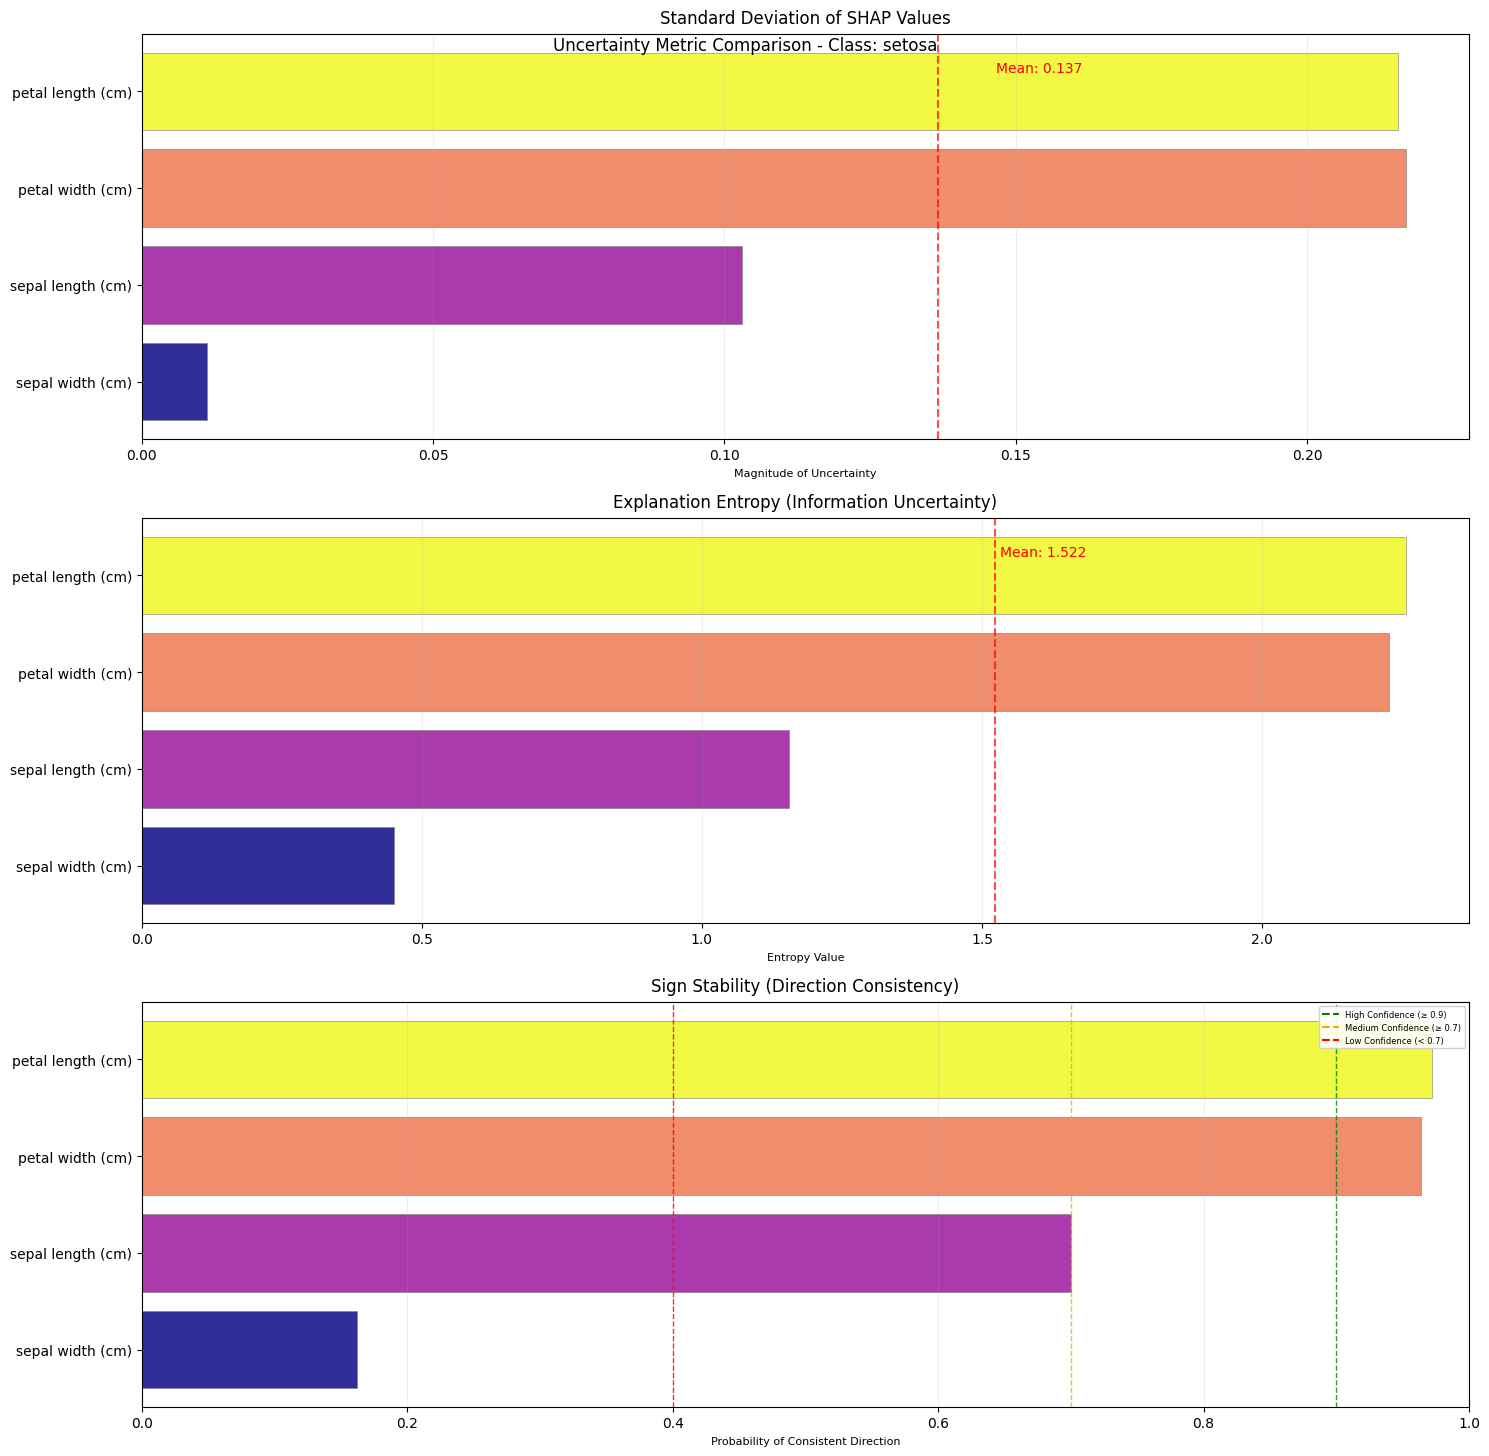


Explaining for class: versicolor


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 573.99it/s]


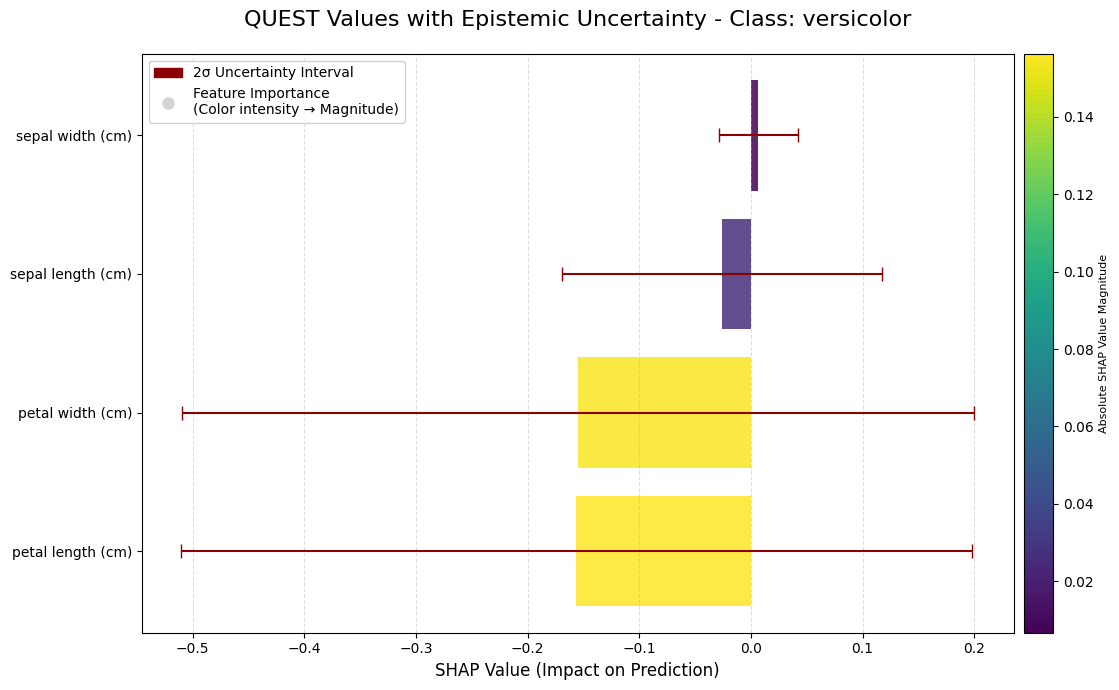

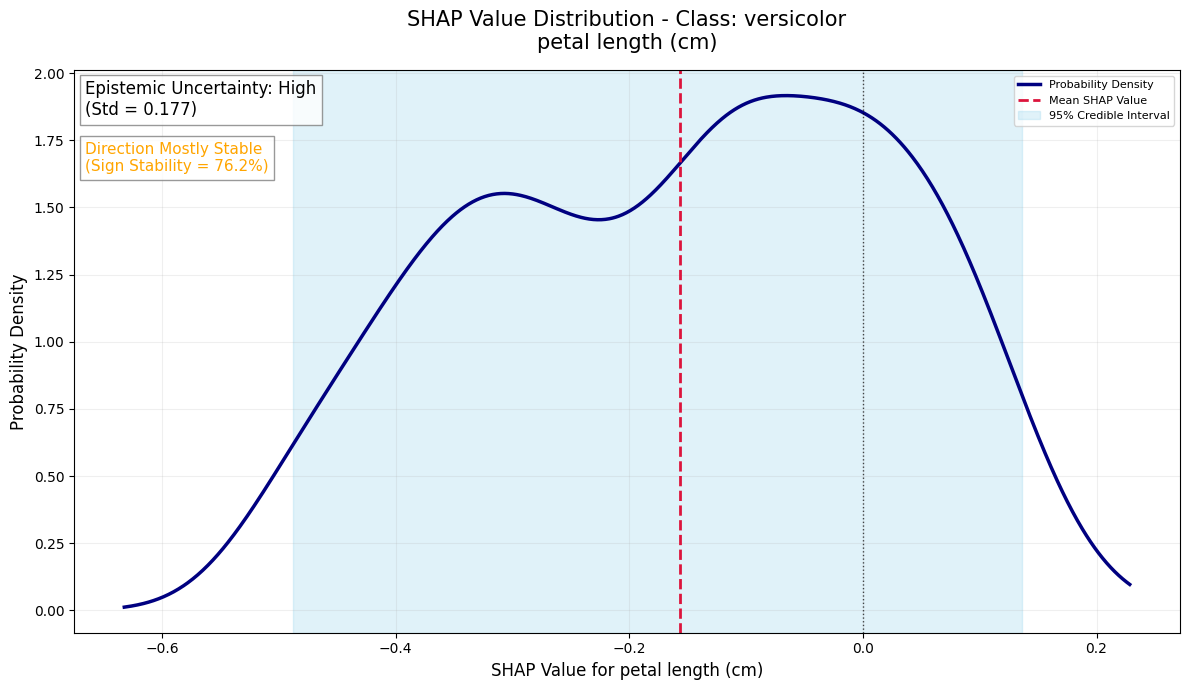

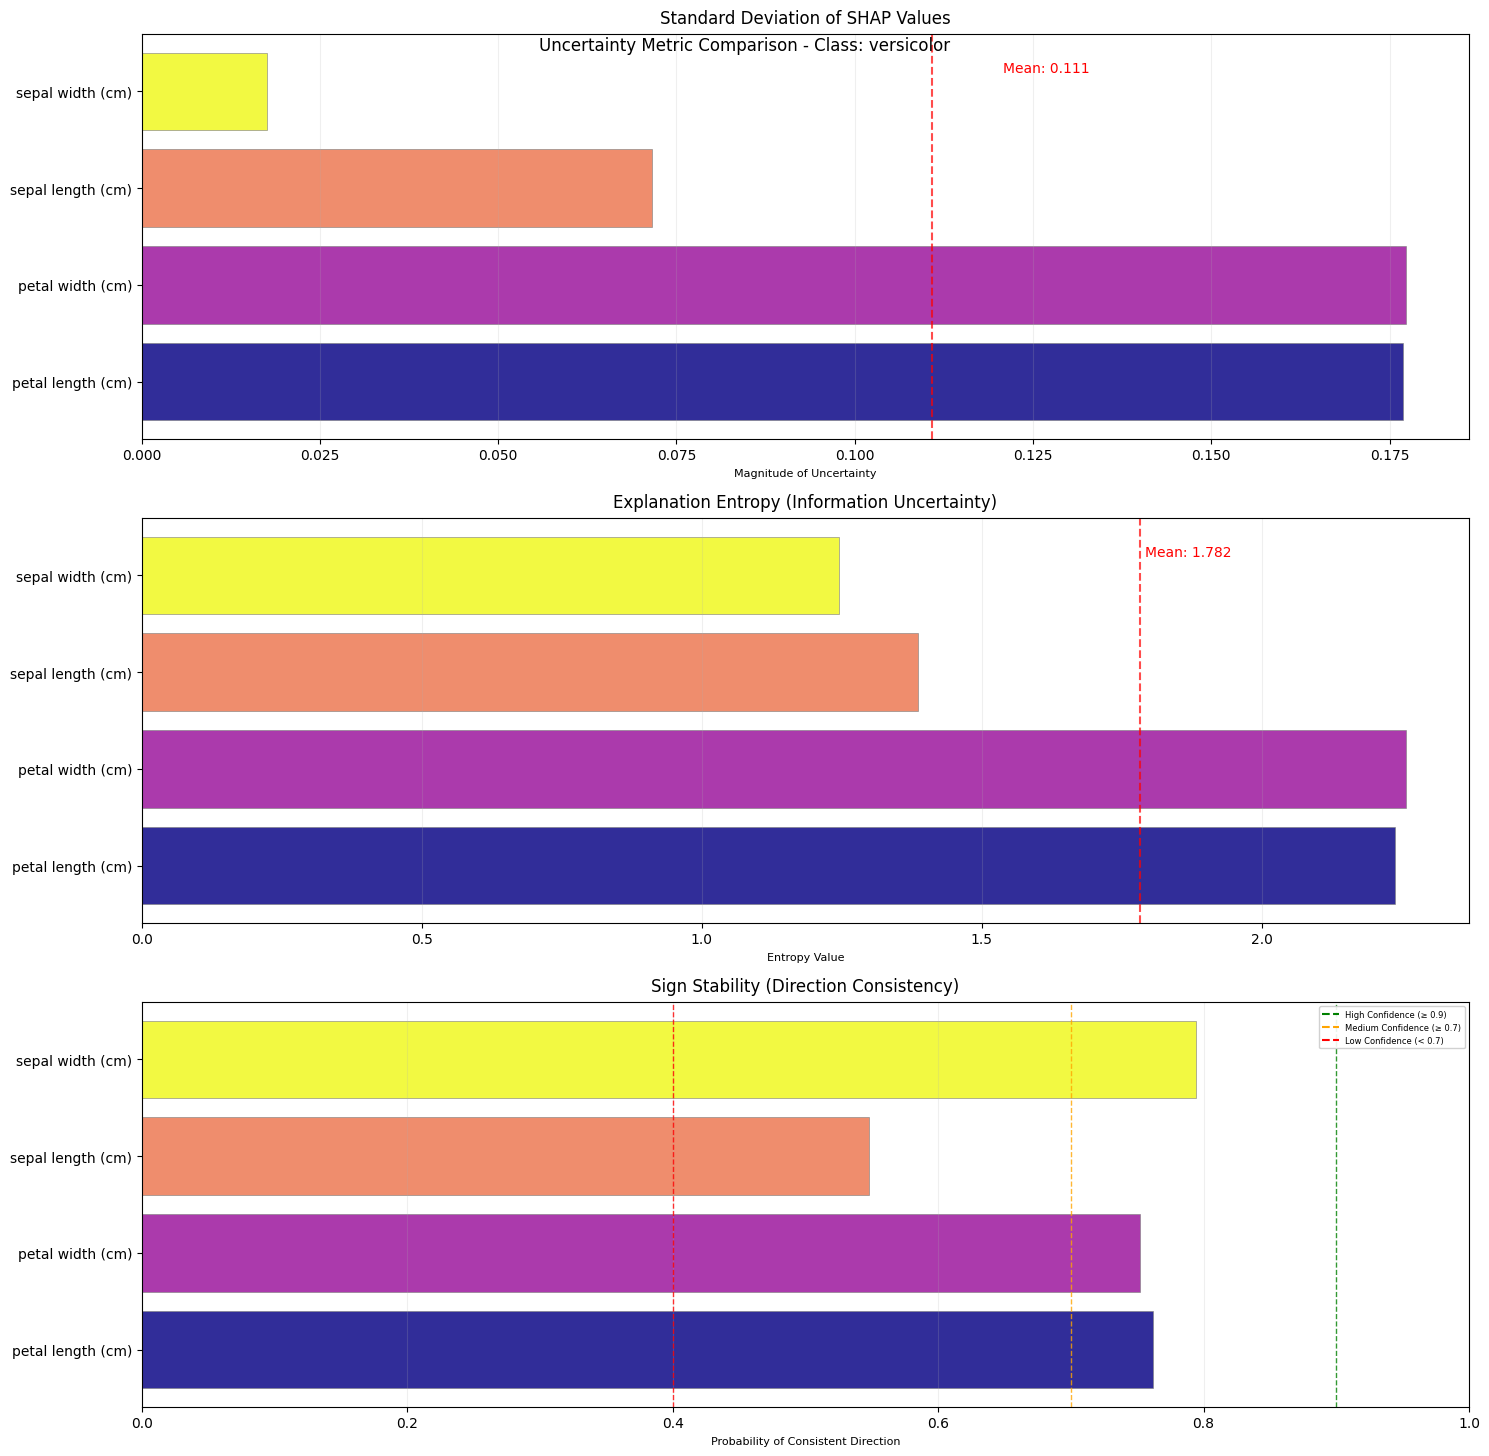


Explaining for class: virginica


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 594.31it/s]


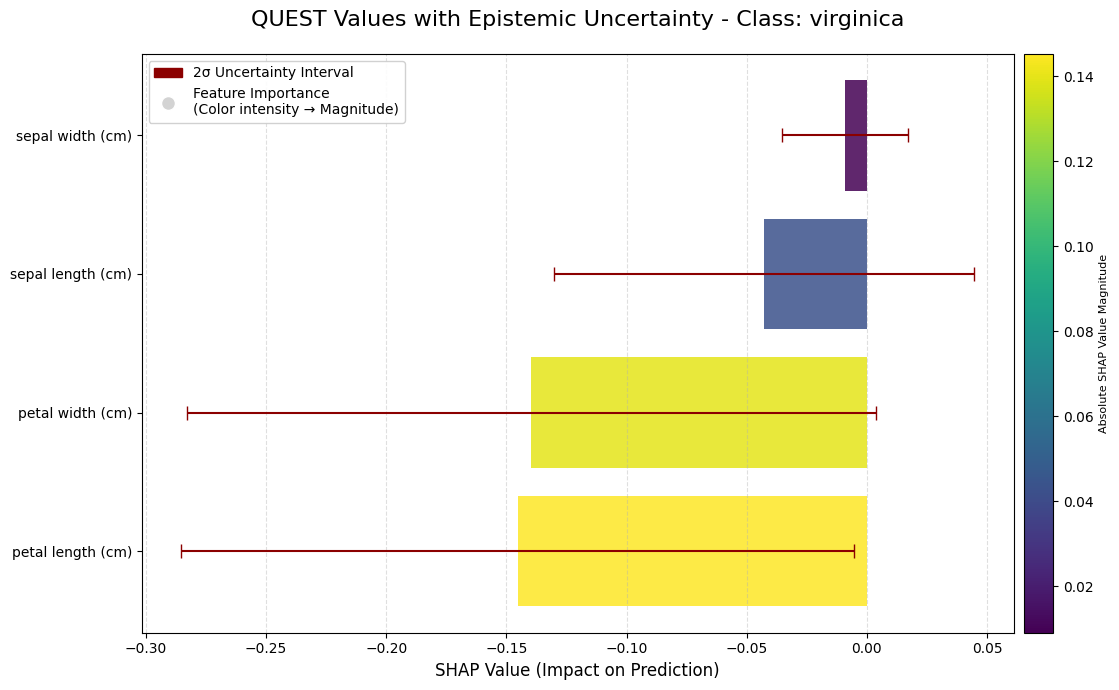

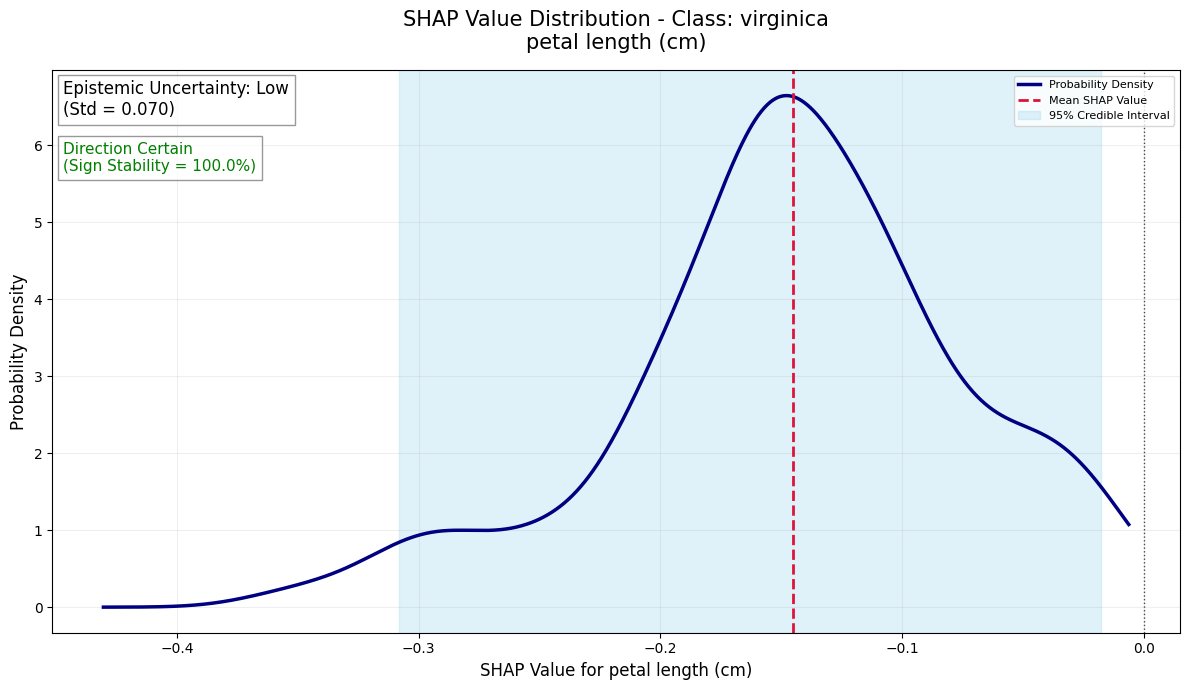

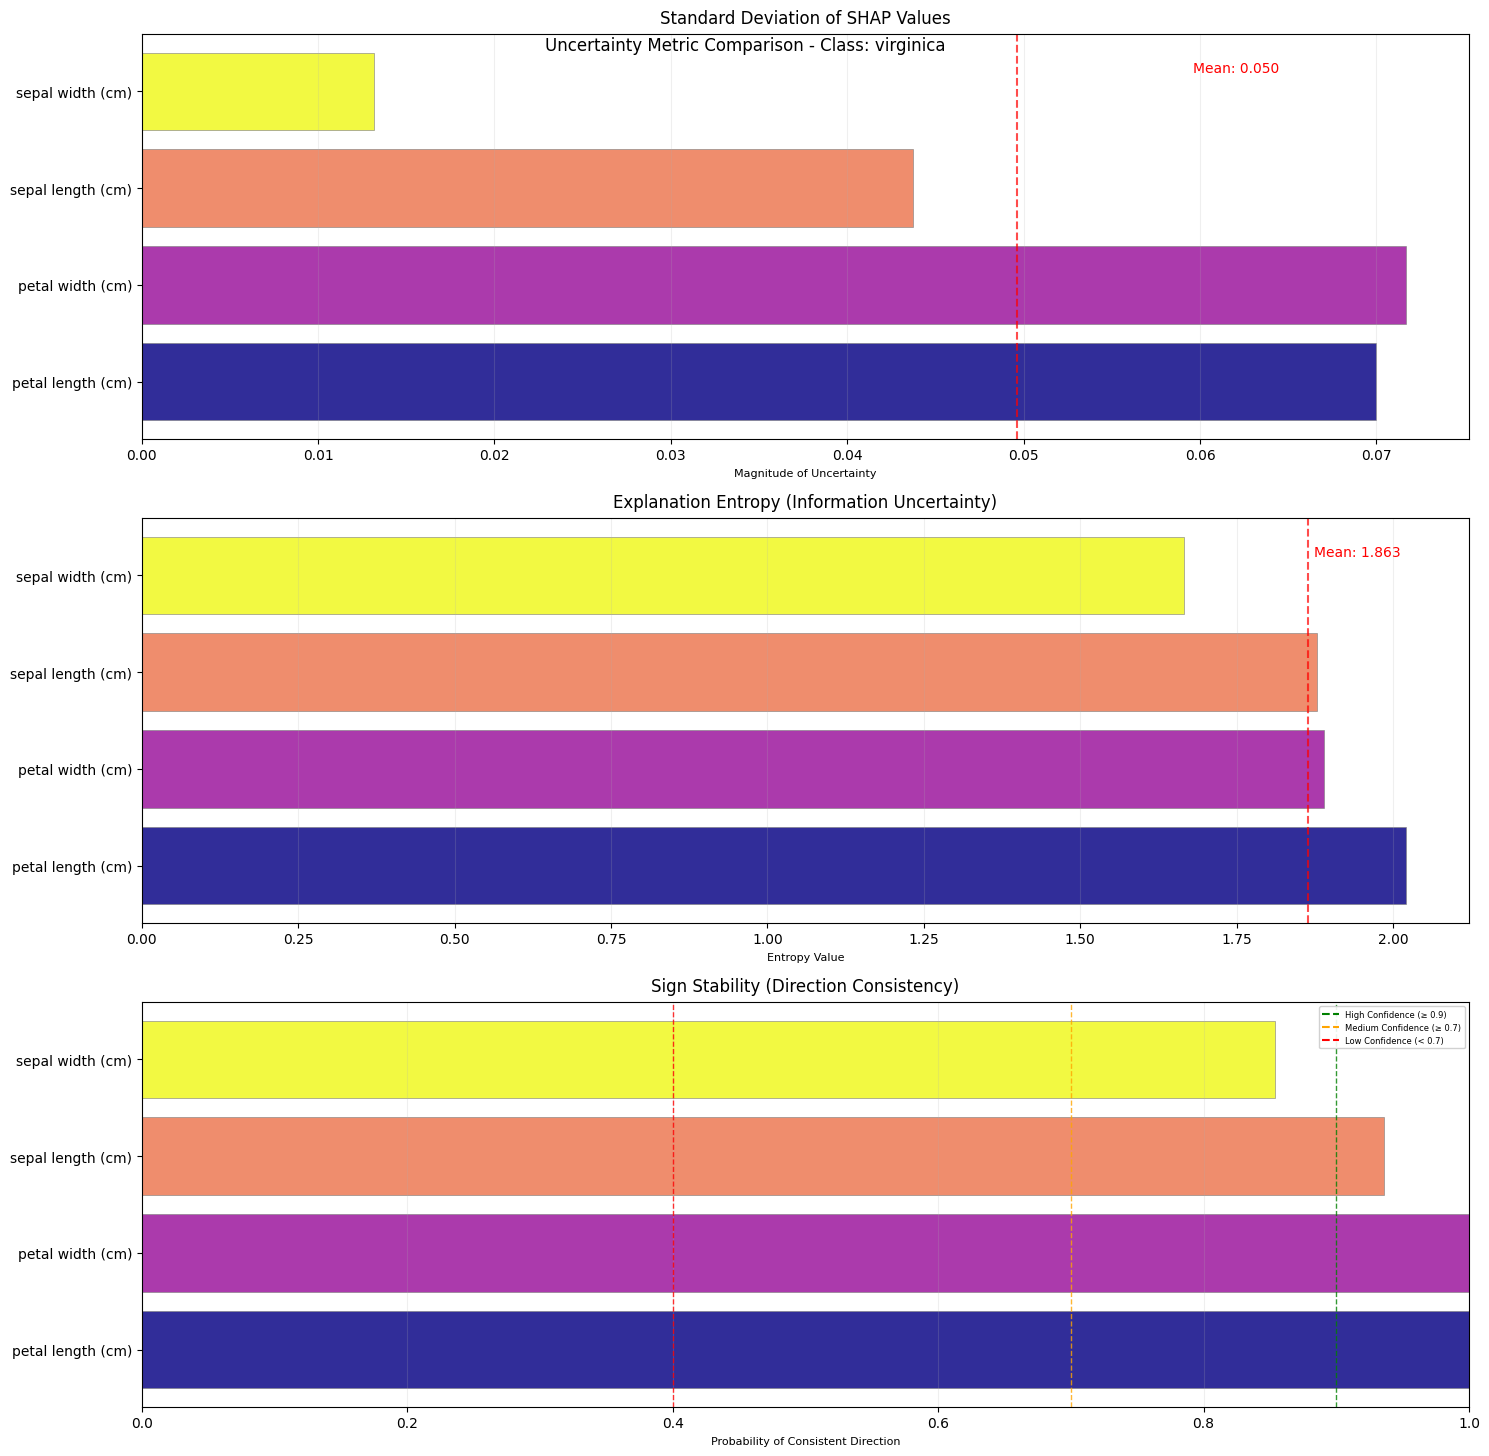

In [1]:
from QUEST import QUESTExplainerClassification
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Train classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Create explainer
explainer = QUESTExplainerClassification(rf, X, y, beta=5.0, random_state=42)

# Explain first instance for each class
instance = X[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx)
    
    # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    most_important_feature = np.argmax(np.abs(results['mean']))
    explainer.plot_uncertainty_distribution(
        results,
        feature_names,
        most_important_feature,
        class_name=class_name
    )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )